<a href="https://colab.research.google.com/github/carolcalandrine/Analise-churn/blob/main/projeto_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Churn

No cenário empresarial atual, reter clientes é tão, ou mais, importante quanto conquistar novos. O churn é a métrica que mede exatamente isso: a taxa de cancelamento ou evasão de clientes em um determinado período.
Especialmente relevante para modelos de assinatura e varejo recorrente, uma taxa de churn elevada indica insatisfação com produtos ou serviços, comprometendo tanto a receita quanto o crescimento sustentável do negócio. Monitorá-la é, portanto, essencial para entender a saúde financeira da empresa e a experiência do cliente.

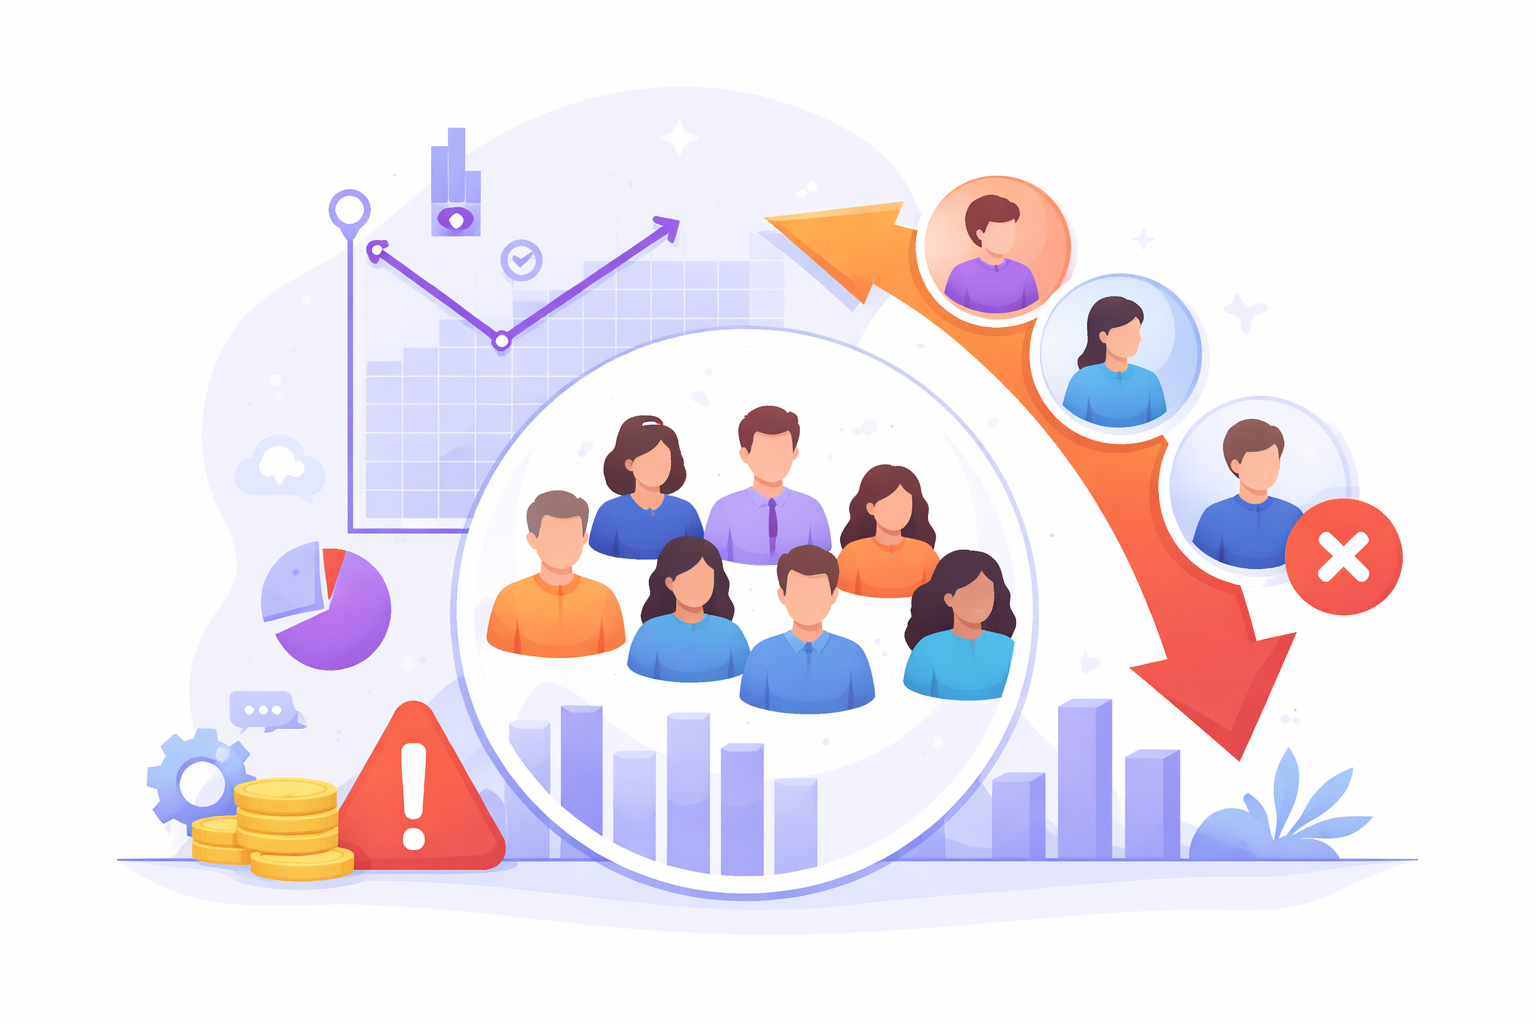

## Objetivo do estudo
Este estudo tem como objetivo realizar uma análise exploratória de dados para investigar o aumento na taxa de churn em uma plataforma de serviços por assinatura, identificando padrões e fatores que contribuem para o cancelamento de clientes.

## Obtenção dos Dados e Importação de Bibliotecas

In [3]:
#importação de bibliotecas
import pandas as pd #manipular tabelas
import numpy as np #operações
import seaborn as sns #manipular gráficos
import matplotlib.pyplot as plt #manipular gráficos

In [4]:
# Importação do arquivo .csv
df = pd.read_csv('/content/sample_data/customer_churn_with_months.csv')

## Dicionário das variáveis

Este é um conjunto de dados de uma empresa de telecomunicações que oferece soluções no modelo Software as a Service (SaaS). Cada variável arquivo .csv é descrita abaixo. O arquivo possui 23 colunas.

- `customerID`: Identificador único para cada cliente distinto
- `Tipo de empresa`: Os valores possíveis são 'Micro empresa' ou 'Pequena empresa'
- `Fundação da empresa`: Anos de fundação
- `Possui mais de sócio`: Sim' se o cliente possuir mais de um sócio, caso contrário, 'Não'
- `Funcionários`: Os valores possíveis são 'até 5 funcionários' e '6 ou mais funcionários'
- `Meses de permanência`: número de meses em que o cliente faz parte da empresa
- `Utiliza serviços financeiros`: Sim' se o cliente utilizou serviços financeiros, caso contrário, 'Não'
- `PossuiContador`: Sim' se o cliente possuir contador, caso contrário, 'Não'
- `Faz conciliação bancária`: Os valores possíveis são 'automática', 'manual' e 'não faz'
- `Módulo financeiro`: Os valores possíveis são 'Uso frequente', 'Pouco uso' e 'Nunca utilizou'
- `Emissão de nota fiscal`: Os valores possíveis são 'Uso frequente', 'Pouco uso' e 'Nunca utilizou'
- `Relatórios`: Os valores possíveis são 'Uso frequente', 'Pouco uso' e 'Nunca utilizou'
- `Integração bancária`: Os valores possíveis são 'Uso frequente', 'Pouco uso' e 'Nunca utilizou'
- `Módulo de vendas`: Os valores possíveis são 'Uso frequente', 'Pouco uso' e 'Nunca utilizou'
- `Utilização de APIs de integração`: Os valores possíveis são 'automática', 'manual' e 'não faz'
- `Contrato`: Os valores possíveis são 'Mês-a-mês', 'Trimestral' e 'Anual'
- `Emite boletos`: 1 se sim, 0 se não
- `Emite boletos.1`: 'Yes' se o cliente cliente emitiu boletos, caso contrário, 'No'
- `Tipo de pagamento`: Os valores possíveis são 'Boleto - pagamento único', 'Boleto - mês a mês', 'Cartão de crédito - pagamento único' e 'Cartão de crédito - mês a mês'
- `Receita mensal`: O valor total pago mensalmente pelo cliente à empresa.
- `Receita total`: O valor acumulado que o cliente pagou à empresa
- `Churn`: 'Sim' se o cliente cancelou o serviço no último mês, caso contrário, 'Não'.
- `mes_churn`: O mês que ocorreu o churn   

## Visão Geral dos Dados

In [5]:
# Overview da tabela
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')

# Limpar os nomes das colunas
df.columns = df.columns.str.strip()  #Remove espaços desnecessários

info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': round(df.isnull().mean() * 100,2),
    'Valores únicos': df.nunique(),
    'Exemplo de valores': df.apply(lambda x: x.unique()[:3])
})
info

Linhas: 7043 | Colunas: 23


,Tipo,Nulos,% Nulos,Valores únicos,Exemplo de valores
ID,int64,0,0.00,7043,"[1, 2, 4]"
Tipo de empresa,object,0,0.00,2,"[Micro empresa, Pequena empresa]"
Fundação da empresa,int64,0,0.00,21,"[2016, 2018, 2019]"
Possui mais de um sócio,object,0,0.00,2,"[Sim, Não]"
Funcionários,object,0,0.00,2,"[até 5 funcionários, 6 ou mais funcionários]"
Meses de permanência,int64,0,0.00,73,"[1, 34, 45]"
Utiliza serviços financeiros,object,0,0.00,2,"[Não, Sim]"
PossuiContador,object,682,9.68,2,"[nan, Não , Sim]"
Faz conciliação bancária,object,0,0.00,3,"[automática, manual, não faz]"
Frequência de utilização de feature do sistema: Módulo financeiro,object,0,0.00,3,"[Pouco uso, Uso frequente, Nunca utilizou]"


In [6]:
condition_dupl = df.duplicated()
df[condition_dupl]

,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn


**Porcentagem de valores ausentes**

Pode-se notar que algumas variáveis apresentam valores ausentes:
- As colunas da variável **Possui Contador** apresentam 9,68% de valores faltantes;
- A variável **Receita total** possui 0,16%, enquanto a váriavel **Mês churn** apresenta 73,46%.

As demais variáveis não possuem valores ausentes.

## Exploração Univariada

Nessa análise vai ajudar a entender a distribuição, detectar problemas de qualidade dos dados e ajudar a elaborar os primeiros insights.

#### Variáveis Categóricas



Tipo de empresa

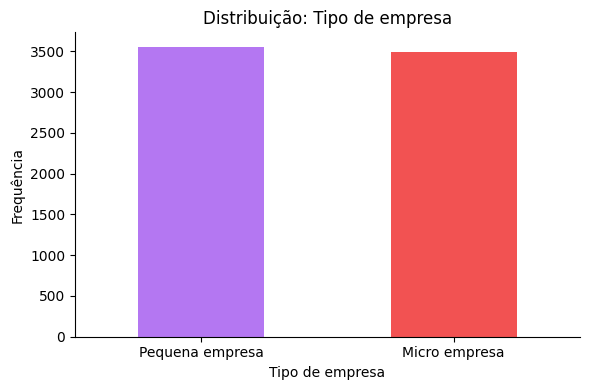

Valores únicos: ['Micro empresa' 'Pequena empresa']
Frequência absoluta: Tipo de empresa
Pequena empresa    3555
Micro empresa      3488
Frequência relativa: Tipo de empresa
Pequena empresa    50.48
Micro empresa      49.52


In [7]:
# @title
# Análise da coluna 'Tipo de empresa'

col = 'Tipo de empresa' #col é o nome da coluna (variável)

# Valores únicos
valores_unicos = df[col].unique()

# Frequência Absoluta e Relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True)* 100,2)

# Visualização
fig, ax = plt.subplots(figsize=(6,4)) #Define o tamanho da imagem
freq_abs.plot(kind='bar', color=['#B477F2', '#F25252']) #kind=bar é o tipo de gráfico, color= cor do gráfico
plt.title('Distribuição: Tipo de empresa') #titulo
plt.xlabel('Tipo de empresa') #nome dos eixos
plt.ylabel('Frequência')
plt.xticks(rotation=0) # rotação
plt.tight_layout() #Ajusta o layout
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Possui mais de um sócio

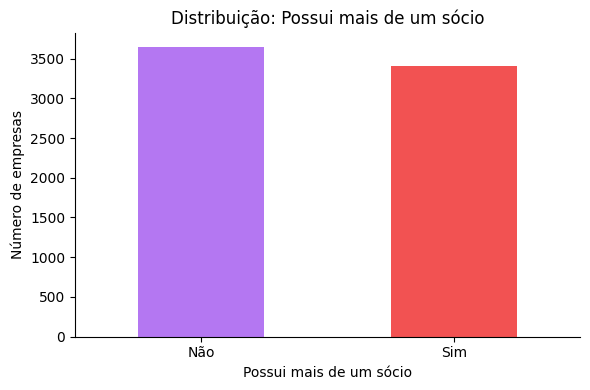

Valores únicos: ['Sim' 'Não']
Frequência absoluta: Possui mais de um sócio
Não    3641
Sim    3402
Frequência relativa: Possui mais de um sócio
Não    51.7
Sim    48.3


In [8]:
# @title
# Análise da coluna 'Possui mais de um sócio'

col = 'Possui mais de um sócio'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência Relativa e Absoluta
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Visualização
fig, ax = plt.subplots(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#B477F2', '#F25252'])
plt.title('Distribuição: Possui mais de um sócio')
plt.xlabel('Possui mais de um sócio')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Funcionários

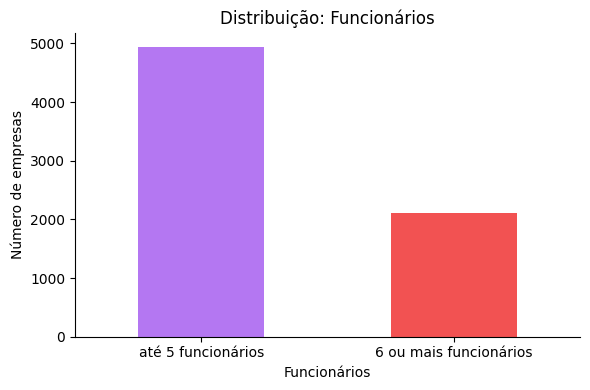

Valores únicos: ['até 5 funcionários' '6 ou mais funcionários']
Frequência absoluta: Funcionários
até 5 funcionários        4933
6 ou mais funcionários    2110
Frequência relativa: Funcionários
até 5 funcionários        70.04
6 ou mais funcionários    29.96


In [9]:
# @title
# Análise da variável 'Funcionários'
col = 'Funcionários'

#Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Visualização
fig, ax = plt.subplots(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#B477F2', '#F25252'])
plt.title('Distribuição: Funcionários')
plt.xlabel('Funcionários')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Utiliza Serviços Financeiros

Valores únicos: ['Não' 'Sim']


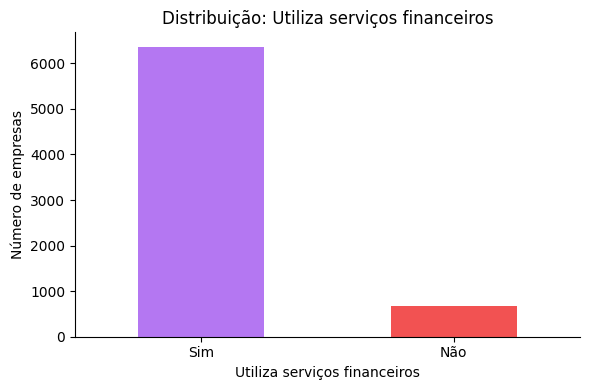

Valores únicos: ['Não' 'Sim']
Frequência absoluta: Utiliza serviços financeiros
Sim    6361
Não     682
Frequência relativa: Utiliza serviços financeiros
Sim    90.32
Não     9.68


In [10]:
# @title
# Análise da coluna 'Utiliza serviços financeiros'
col = 'Utiliza serviços financeiros'

# Valores únicos
valores_unicos = df[col].unique()
print(f'Valores únicos: {df[col].unique()}')

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Gráfico
fig, ax = plt.subplots(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#B477F2', '#F25252'])
plt.title('Distribuição: Utiliza serviços financeiros')
plt.xlabel('Utiliza serviços financeiros')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')


Essa variável é uma variável categórica ordinal. Sendo assim pode-se dizer que a maioria dos clientes utilizam serviços financeiros. Então qual seria a relação do churn com essa variável? Quem possui ou não serviços financeiros tende a cancelar a assinatura ?

Possui Contador

Valores únicos: [nan 'Não ' 'Sim']


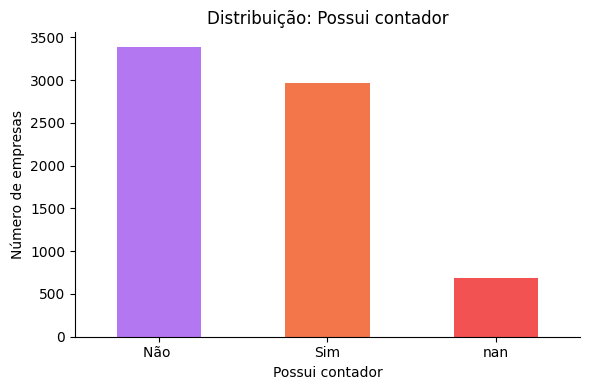

Valores únicos: [nan 'Não ' 'Sim']
Frequência absoluta: PossuiContador
Não     3390
Sim     2971
NaN      682
Frequência relativa: PossuiContador
Não     48.13
Sim     42.18
NaN      9.68


In [11]:
# @title
#Análise da coluna 'PossuiContador'
col = 'PossuiContador'

#Valores unicos
valores_unicos = df[col].unique()
print(f'Valores únicos: {valores_unicos}')

#Nulos
nulos = df[col].isnull().sum()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts(dropna=False) # dropna=False para considerar os valores vazios
freq_rel = round(df[col].value_counts(normalize=True, dropna=False) * 100,2)

# Gráfico de barra
fig, ax = plt.subplots(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#B477F2', '#F27649', '#F25252'])
plt.title('Distribuição: Possui contador')
plt.xlabel('Possui contador')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Esse 'nan' seriam os valores vazios que não obtiveram resultados em relação a pergunta: se o cliente possui ou não contador sendo 9,68%

Faz conciliação bancária

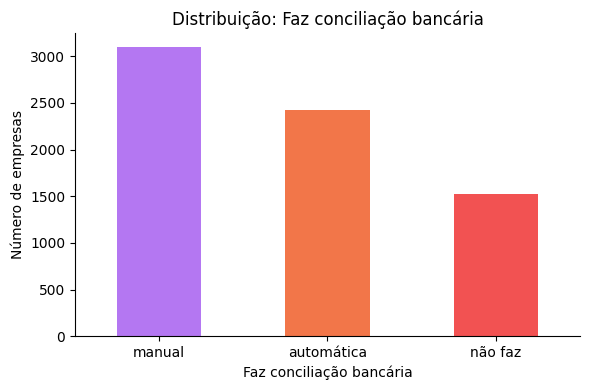

Valores únicos: ['automática' 'manual' 'não faz']
Frequência absoluta: Faz conciliação bancária
manual        3096
automática    2421
não faz       1526
Frequência relativa: Faz conciliação bancária
manual        43.96
automática    34.37
não faz       21.67


In [12]:
# @title
# Análise da coluna 'Faz conciliação bancária'

col = 'Faz conciliação bancária'

#Valores únicos
valores_unicos = df[col].unique()

#Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

# Gráfico
fig, ax = plt.subplots(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#B477F2', '#F27649', '#F25252'])
plt.title('Distribuição: Faz conciliação bancária')
plt.xlabel('Faz conciliação bancária')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Frequência da utilização das features

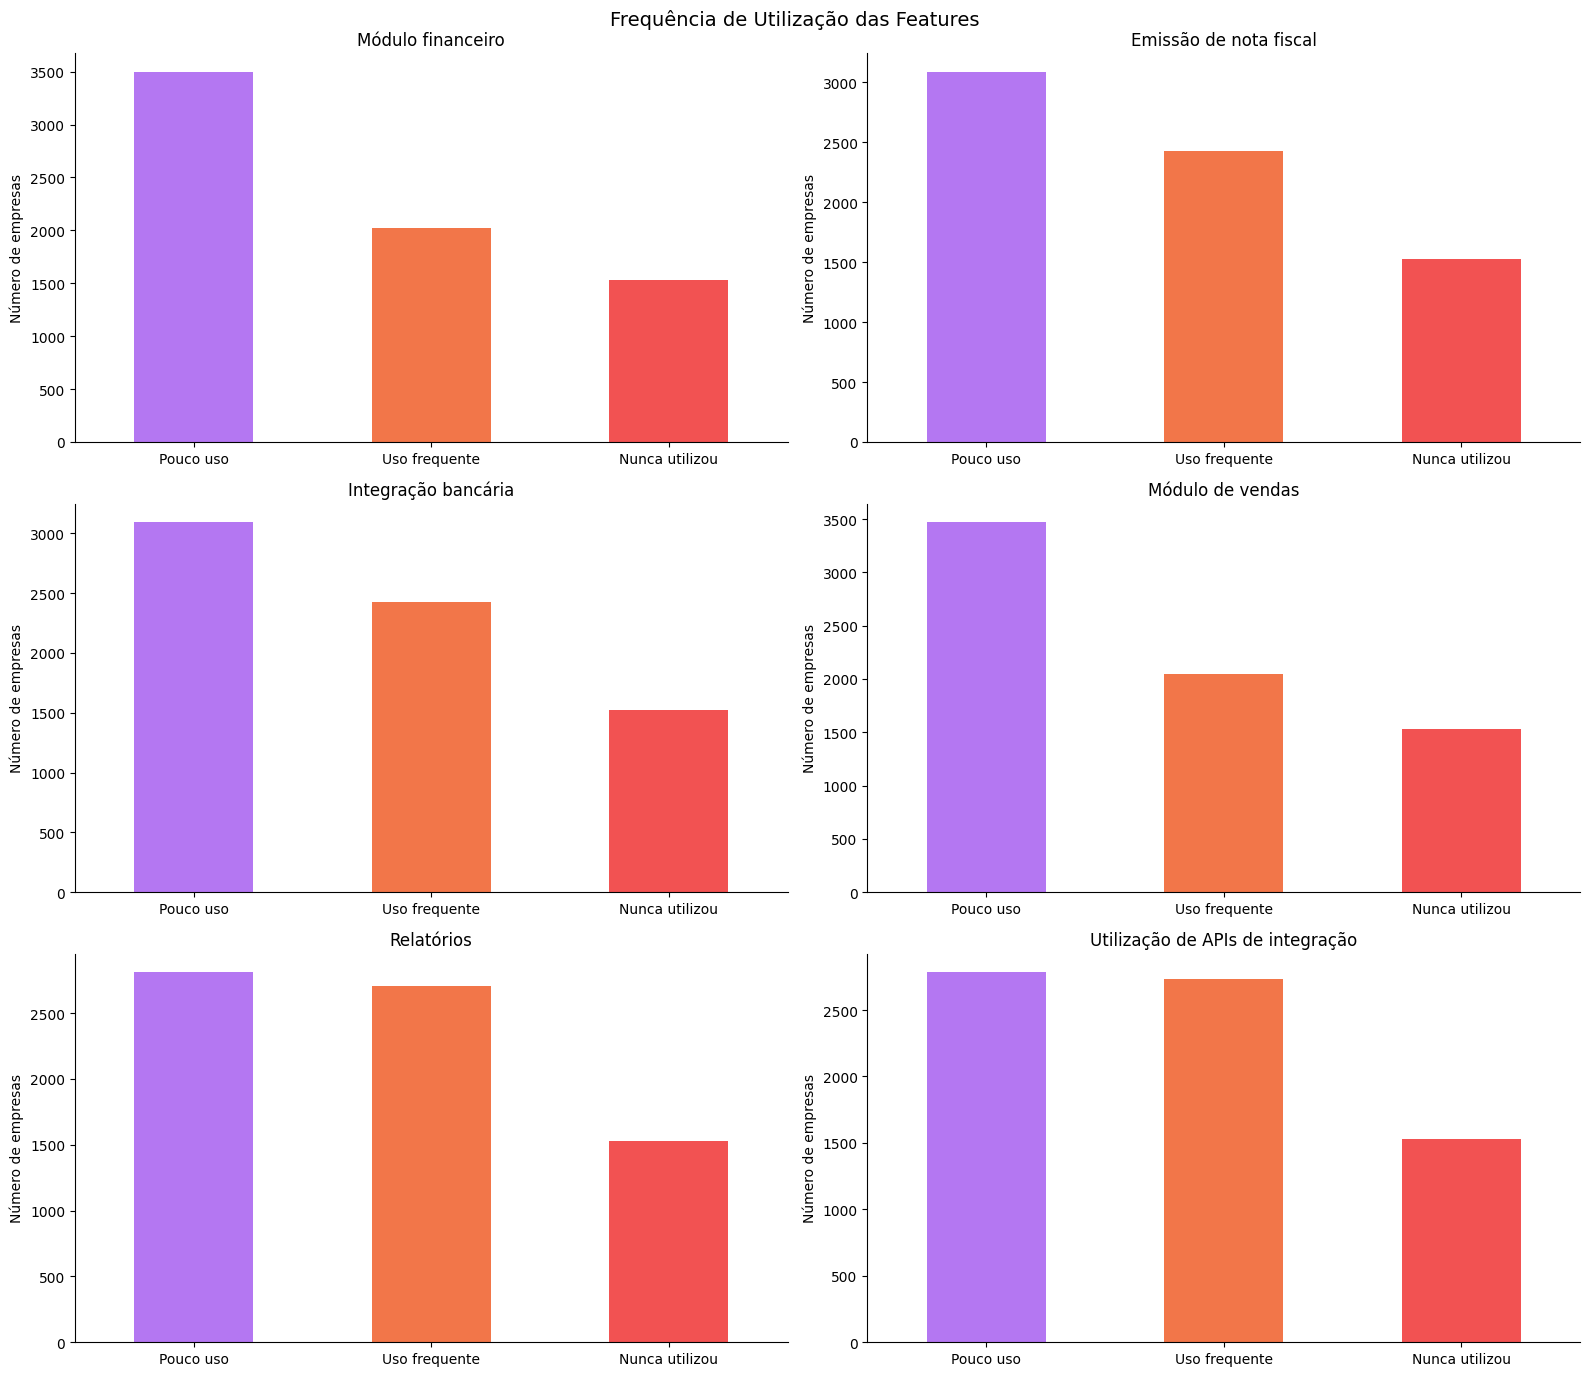


Módulo financeiro
Pouco uso            3498
Uso frequente        2019
Nunca utilizou       1526

Emissão de nota fiscal
Pouco uso            3088
Uso frequente        2429
Nunca utilizou       1526

Integração bancária
Pouco uso            3095
Uso frequente        2422
Nunca utilizou       1526

Módulo de vendas
Pouco uso            3473
Uso frequente        2044
Nunca utilizou       1526

Relatórios
Pouco uso            2810
Uso frequente        2707
Nunca utilizou       1526

Utilização de APIs de integração
Pouco uso            2785
Uso frequente        2732
Nunca utilizou       1526


In [13]:
# @title
# Colunas de frequência de uso
freq_cols = [
    'Frequência de utilização de feature do sistema: Módulo financeiro',
    'Frequência de utilização de feature do sistema: Emissão de nota fiscal',
    'Frequência de utilização de feature do sistema: Integração bancária',
    'Frequência de utilização de feature do sistema: Módulo de vendas',
    'Frequência de utilização de feature do sistema: Relatórios',
    'Frequência de utilização de feature do sistema: Utilização de APIs de integração'
]

fig, axs = plt.subplots(3, 2, figsize=(16, 14))
for i, col in enumerate(freq_cols):
    freq_abs = df[col].value_counts()
    ax = axs[i//2, i%2]
    freq_abs.plot(kind='bar', color=['#B477F2', '#F27649', '#F25252'], ax=ax)
    ax.set_title(col.replace('Frequência de utilização de feature do sistema: ', ''))
    ax.set_ylabel('Número de empresas')
    ax.set_xlabel('')
    ax.set_xticklabels(freq_abs.index, rotation=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Frequência de Utilização das Features', fontsize=14)
plt.tight_layout()
plt.show()

numeros_reais = {col: df[col].value_counts() for col in freq_cols}
for col, counts in numeros_reais.items():
    nome = col.replace("Frequência de utilização de feature do sistema: ", "")
    print(f'\n{nome}')
    for categoria, valor in counts.items():
        print(f'{categoria:<20} {valor}')

Contrato

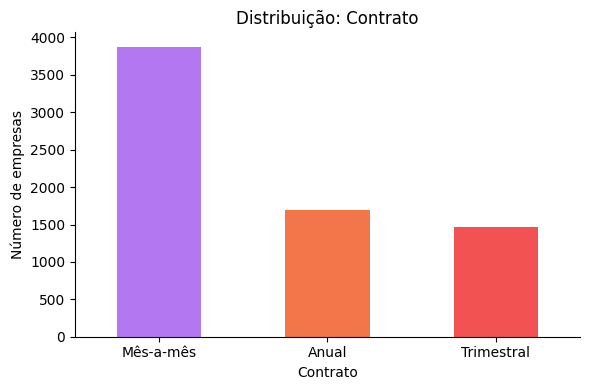

Valores únicos: ['Mês-a-mês' 'Trimestral' 'Anual']
Frequência absoluta: Contrato
Mês-a-mês     3875
Anual         1695
Trimestral    1473
Frequência relativa: Contrato
Mês-a-mês     55.02
Anual         24.07
Trimestral    20.91


In [14]:
# @title
# Análise da coluna 'Contrato'
col = 'Contrato'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)

#Gráfico
fig, ax = plt.subplots(figsize=(6,4))
freq_abs.plot(kind= 'bar', color= ['#B477F2', '#F27649', '#F25252'])
plt.title('Distribuição: Contrato')
plt.xlabel('Contrato')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Emite boletos

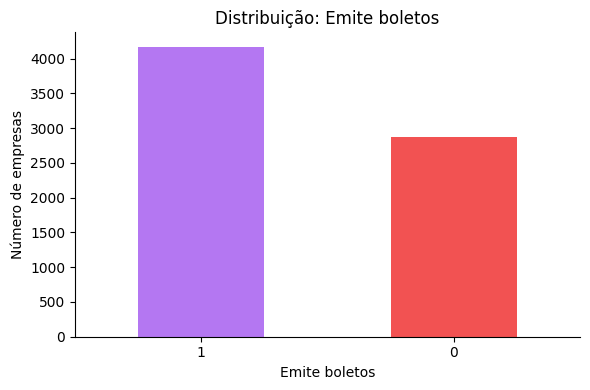

Valores únicos: [1 0]
Frequência absoluta: Emite boletos
1    4171
0    2872
Frequência relativa: Emite boletos
1    59.22
0    40.78


In [15]:
# @title
# Análise da coluna 'Emite boletos'
col = 'Emite boletos'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Gráfico
fig, ax = plt.subplots(figsize=(6,4))
freq_abs.plot(kind= 'bar', color= ['#B477F2', '#F25252'])
plt.title('Distribuição: Emite boletos')
plt.xlabel('Emite boletos')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Tipo de pagamento

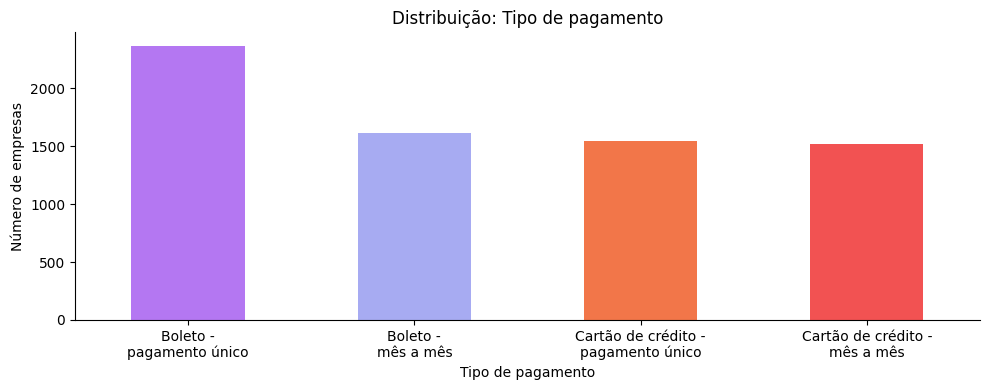

Valores únicos:['Boleto - pagamento único' 'Boleto - mês a mês'
 'Cartão de crédito - pagamento único' 'Cartão de crédito - mês a mês']
Frequência absoluta: Tipo de pagamento
Boleto - pagamento único               2365
Boleto - mês a mês                     1612
Cartão de crédito - pagamento único    1544
Cartão de crédito - mês a mês          1522
Frequência relativa: Tipo de pagamento
Boleto - pagamento único               33.58
Boleto - mês a mês                     22.89
Cartão de crédito - pagamento único    21.92
Cartão de crédito - mês a mês          21.61


In [16]:
# @title
# Análise da coluna 'Tipo de pagamento'

col = 'Tipo de pagamento'
nomes = {
    'Boleto - pagamento único': 'Boleto -\npagamento único',
    'Boleto - mês a mês': 'Boleto -\nmês a mês',
    'Cartão de crédito - pagamento único': 'Cartão de crédito -\npagamento único',
    'Cartão de crédito - mês a mês': 'Cartão de crédito -\nmês a mês'
}

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_plot = freq_abs.rename(index=nomes)
freq_rel = round(df[col].value_counts(normalize=True) * 100,2)


# Gráfico

fig, ax= plt.subplots(figsize=(10,4))
freq_plot.plot(kind= 'bar', color= ['#B477F2', '#A7ABF2', '#F27649', '#F25252'])  # Para o gráfico renomeado
plt.title('Distribuição: Tipo de pagamento')
plt.xlabel('Tipo de pagamento')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos:{valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Churn

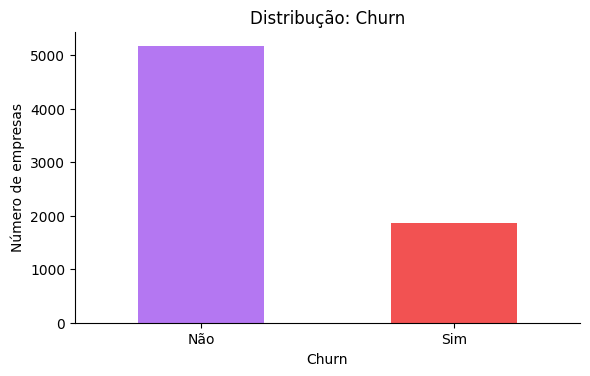

Valores Únicos:['Não' 'Sim']
Frequência absoluta: Churn
Não    5174
Sim    1869
Frequência relativa: Churn
Não    73.46
Sim    26.54


In [17]:
# @title
# Análise coluna 'Churn'

col = 'Churn'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True) * 100, 2)

# Gráfico
fig, ax = plt.subplots(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#B477F2', '#F25252'])
plt.title('Distribução: Churn')
plt.xlabel('Churn')
plt.ylabel('Número de empresas')
plt.tight_layout()
plt.xticks(rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores Únicos:{valores_unicos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

Mês churn

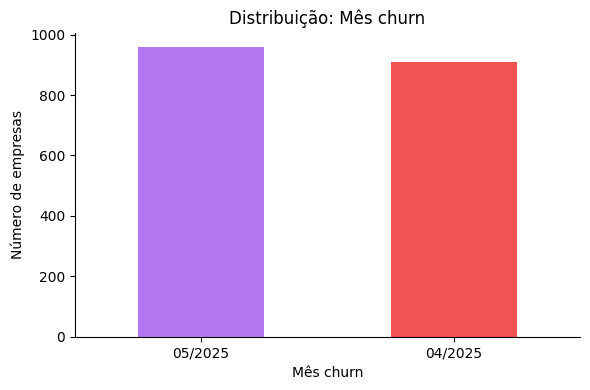

Valores únicos: [nan '04/2025' '05/2025']
Valores nulos: 5174
Frequência absoluta: mes_churn
NaN        5174
05/2025     958
04/2025     911
Frequência relativa: mes_churn
NaN        73.46
05/2025    13.60
04/2025    12.93


In [18]:
# @title
# Análise da coluna 'mes_churn'

col = 'mes_churn'

#Valores únicos
valores_unicos = df[col].unique()

#Valores nulos
nulos = df[col].isnull().sum()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts(dropna=False)
freq_rel = round(df[col].value_counts(dropna=False, normalize=True) * 100, 2)

# Gráfico
fig, ax = plt.subplots(figsize=(6,4))
df[col].dropna().value_counts().plot(kind= 'bar', color= ['#B477F2', '#F25252'])
plt.title('Distribuição: Mês churn')
plt.xlabel('Mês churn')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {valores_unicos}')
print(f'Valores nulos: {nulos}')
print(f'Frequência absoluta: {freq_abs.to_string()}')
print(f'Frequência relativa: {freq_rel.to_string()}')

**Análise das Variáveis Categóricas**

Nos gráficos foram selecionadas as variáveis categóricas para entender a distribuição, detectar valores inconsistentes e elaborar os primeiros insights.

**Análise geral**
- Entre todas as variáveis, apenas **Possui contador** e **Mês Churn** apresentam valores ausentes;
- Todas as variáveis de **Utilização de Features** apresentam exatamente 1.526 clientes que nunca utilizaram nenhum recurso o que pode indicar um grupo de clientes com baixo engajamento;
- A variável **Emite Boletos** possui duas colunas com os mesmos valores.

**Análise das colunas**
- A base é composta por micro e pequenas empresas, com 70% dos clientes possuindo até 5 funcionários, o que indica que o produto é mais adotado por empresas de menor porte, possivelmente com menor orçamento para ferramentas de gestão;
- A variável **Possui mais de um sócio** apresenta distribuição equilibrada entre as categorias (51,7% Não e 48,3% Sim), não sendo possível identificar predominância de nenhum grupo;
- 90,32% das empresas **utilizam serviços financeiros**, o que indica que esse recurso é quase universal na base. Clientes que não utilizam podem representar um perfil diferenciado a ser investigado;
- Na variável **Possui contador**, 48,13% responderam Não e 42,18% responderam Sim, com 9,68% de valores ausentes que requerem atenção;
- A maioria dos clientes faz **pouco uso das features de engajamento**, o que pode indicar baixa adoção do produto e maior tendência de cancelamento;
- A variável **Contrato** mostra que 55% dos clientes optam pelo plano mensal — modalidade que oferece menor compromisso e maior facilidade de cancelamento;
- A predominância do **boleto - pagamento único** como forma de pagamento está alinhada com o perfil de contrato mensal, podendo estar relacionada à taxa de churn;
- O **Mês Churn** indica aumento nos cancelamentos de abril (12,93%) para maio (13,60%) de 2025, o que será investigado na análise bivariada.







### Variáveis Numéricas

Fundação da empresa

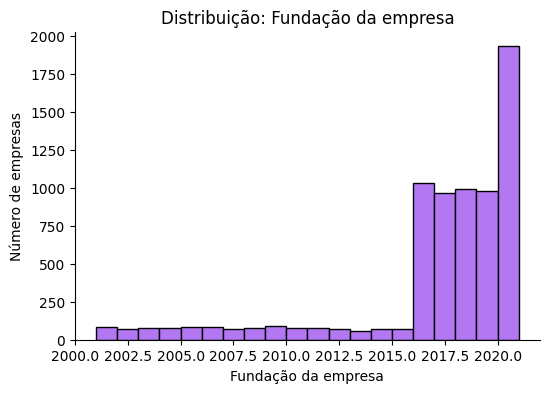

Valores únicos: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Estatística descritiva:
count    7043.00
mean     2016.74
std         4.58
min      2001.00
25%      2016.00
50%      2018.00
75%      2020.00
max      2021.00
Top 5 anos de fundação: Fundação da empresa
2016    1029
2018     990
2019     982
2021     975
2017     969


In [19]:
## Análise da coluna 'Fundação da empresa'
col = 'Fundação da empresa'  #Extraindo a coluna do DataFrame

#Valores unicos
valores_unicos = df[col].unique() #unique: valores únicos, tolist: transforma em lista, sorted: ordem crescente

# Estatística descritiva
stats = round(df[col].describe(),2)

#Frequência dos anos mais comuns
top_anos = df[col].value_counts().head(5)

#Histograma
fig, ax = plt.subplots(figsize=(6,4))
plt.hist(df[col], bins=20, edgecolor='black', color='#B477F2')
plt.title('Distribuição: Fundação da empresa')
plt.xlabel('Fundação da empresa')
plt.ylabel('Número de empresas')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores únicos: {sorted(valores_unicos.tolist())}')
print(f'Estatística descritiva:\n{stats.to_string()}')
print(f'Top 5 anos de fundação: {top_anos.to_string()}')

Meses de permanência

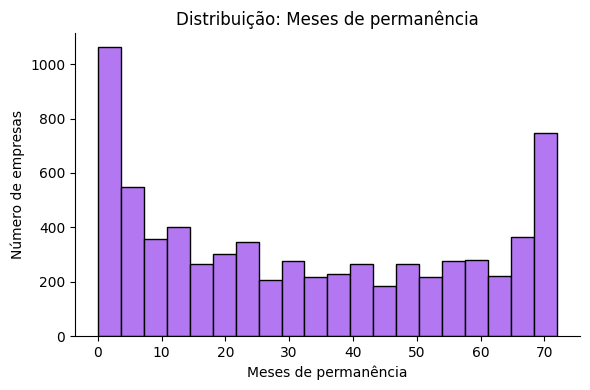

Estatística descritiva:
count    7043.00
mean       32.37
std        24.56
min         0.00
25%         9.00
50%        29.00
75%        55.00
max        72.00


In [20]:
# Análise da coluna 'Meses de permanência'
col = 'Meses de permanência'

# Estatística descritiva
est = round(df[col].describe(),2)

# Histograma
fig, ax = plt.subplots(figsize=(6,4))
plt.hist(df[col], bins=20, edgecolor='black', color= '#B477F2')
plt.title('Distribuição: Meses de permanência')
plt.xlabel('Meses de permanência')
plt.ylabel('Número de empresas')
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print(f'Estatística descritiva:\n{est.to_string()}')

Receita mensal

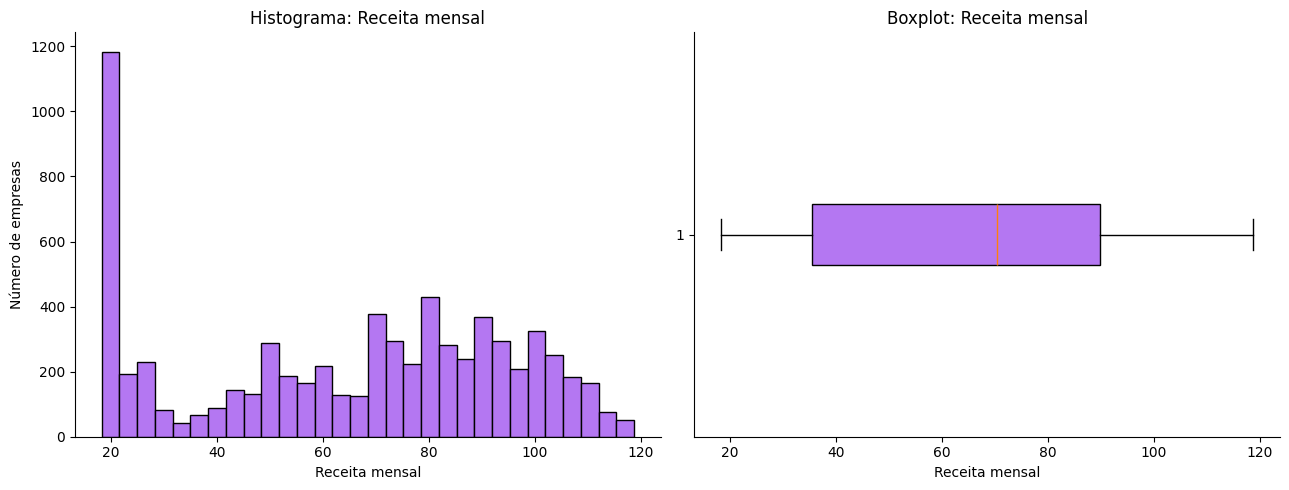

Estatística descritiva:
count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75


In [21]:
# Análise da coluna 'Receita mensal'
col = 'Receita mensal'

# Estatística
est = round(df[col].describe(),2)

# Boxplot e histograma
fig, axs = plt.subplots(1, 2, figsize=(13,5))
axs[0].hist(df[col].dropna(), bins=30, edgecolor='black', color='#B477F2') # dropna retira os Nan (vazios)
axs[0].set_title('Histograma: Receita mensal')  # O .set_ é sempre usado para axs[0]
axs[0].set_xlabel('Receita mensal')
axs[0].set_ylabel('Número de empresas')
axs[1].boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='#B477F2'))   # patch_artist e boxprops para cores
axs[1].set_title('Boxplot: Receita mensal')
axs[1].set_xlabel('Receita mensal')
plt.tight_layout()
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.show()

print(f'Estatística descritiva:\n{est.to_string()}')  #\n para pular a linha

Receita total

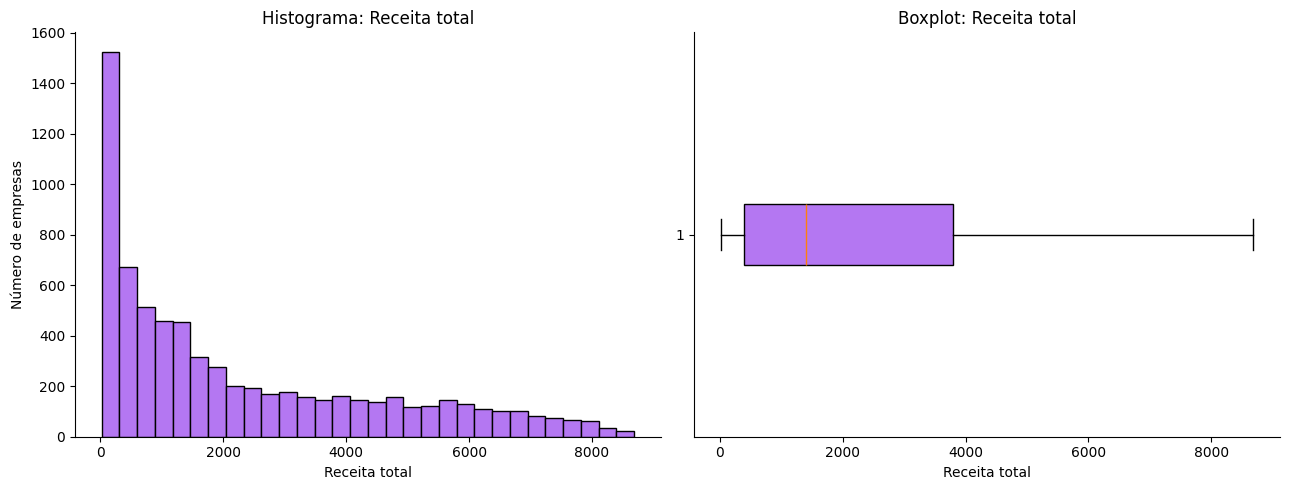

Valores nulos: 11
Estatística descritiva:
count    7032.00
mean     2283.30
std      2266.77
min        18.80
25%       401.45
50%      1397.48
75%      3794.74
max      8684.80


In [22]:
# Análise da coluna 'Receita total'
col = 'Receita total'

# Valores nulos
nulos = df[col].isnull().sum()

# Estatística descritiva
est = round(df[col].describe(),2)

# Boxplot e histograma
fig, axs = plt.subplots(1, 2, figsize=(13,5))
axs[0].hist(df[col].dropna(), bins=30, edgecolor= 'black', color='#B477F2')
axs[0].set_title('Histograma: Receita total')
axs[0].set_xlabel('Receita total')
axs[0].set_ylabel('Número de empresas')
axs[1].boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='#B477F2'))
axs[1].set_title('Boxplot: Receita total')
axs[1].set_xlabel('Receita total')
plt.tight_layout()
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.show()

print(f'Valores nulos: {nulos}')
print(f'Estatística descritiva:\n{est.to_string()}')

**Análise das Variáveis Numéricas**

- A **Fundação da empresa** está concentrada entre 2016 e 2021, com média em 2016 e pico em 2021 indicando que a base é composta majoritariamente por empresas recentes, fundadas nos últimos anos;

- A variável **Meses de permanência** apresenta distribuição bimodal há uma concentração de clientes nos primeiros meses (0-5) e outro grupo fidelizado com mais de 70 meses. A média é de 32 meses, com metade dos clientes permanecendo menos de 29 meses;

- A **Receita mensal** apresenta distribuição assimétrica à direita, com concentração de clientes na faixa de 18 a 35, média de 64,76 e máximo de 118,75. O boxplot não indica outliers expressivos;

- A **Receita total** apresenta forte assimetria à direita, a mediana (1.397) é muito menor que a média (2.283), indicando que a maioria dos clientes gerou pouca receita acumulada. Possui 11 valores nulos que requerem atenção.

## Exploração Multivariada

### Análise temporal

,churns,ativos_inicio_mes,taxa_churn
04/2025,911,6132,14.86
05/2025,958,5174,18.52


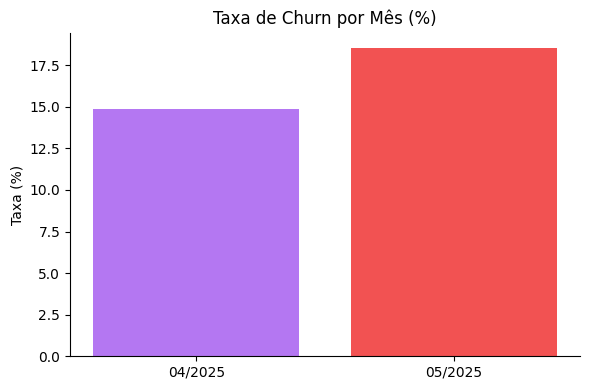

In [23]:
# @title
# Filtrar apenas os clientes que deram churn
churns = df[~df['mes_churn'].isnull()]

# Contar churns por mês
churns_mes = churns['mes_churn'].value_counts().sort_index()

# Calcular clientes ativos por mês
ativos_abril = df.shape[0] - churns_mes.loc['04/2025'] if '04/2025' in churns_mes else df.shape[0]
ativos_maio = ativos_abril - churns_mes.loc['05/2025'] if '05/2025' in churns_mes else ativos_abril

# Construir DataFrame de análise temporal
analise_temporal = pd.DataFrame({
    'churns': churns_mes,
    'ativos_inicio_mes': [ativos_abril, ativos_maio]
}, index=['04/2025', '05/2025'])

analise_temporal['taxa_churn'] = round(analise_temporal['churns'] / analise_temporal['ativos_inicio_mes'] * 100, 2)

display(analise_temporal)

fig, ax = plt.subplots(figsize=(6, 4))

# Taxa de churn
ax.bar(analise_temporal.index, analise_temporal['taxa_churn'], color=['#B477F2', '#F25252'])
ax.set_title('Taxa de Churn por Mês (%)')
ax.set_ylabel('Taxa (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

- Em abril de 2025, foram registrados 911 cancelamentos, representando uma taxa de churn de 14,86% sobre a base ativa do mês;
- Em maio de 2025, os cancelamentos aumentaram para 958, elevando a taxa para 18,52%, um crescimento de 3,66% em relação ao mês anterior;
- É importante ressaltar que com apenas 2 meses de dados não é possível afirmar se esse aumento representa uma tendência de crescimento ou uma variação pontual.







### Agrupamentos

Churn x Tipo de empresa

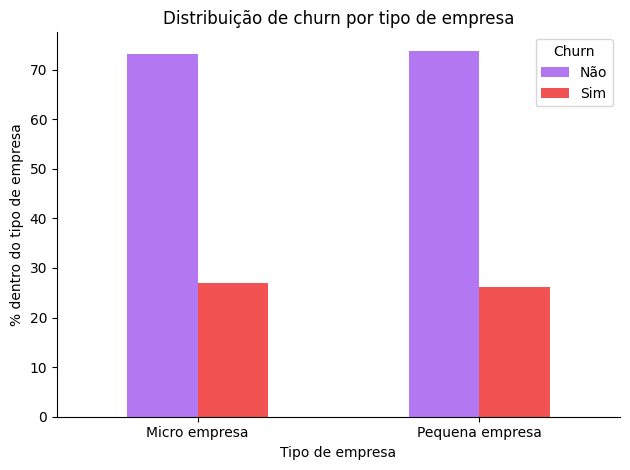

Churn,Não,Sim
Tipo de empresa,,
Micro empresa,73.08,26.92
Pequena empresa,73.84,26.16


In [24]:
# Tabela cruzada
crosstab = round(pd.crosstab(df['Tipo de empresa'], df['Churn'], normalize='index') * 100, 2)

# Gráfico de barras
crosstab = crosstab[['Não', 'Sim']]

ax = crosstab.plot(kind='bar', color= ['#B477F2', '#F25252'])

ax.spines['top'].set_visible(False)    # Remove borda de cima
ax.spines['right'].set_visible(False)

# Plotagem do gráfico
plt.title('Distribuição de churn por tipo de empresa')
plt.xlabel('Tipo de empresa')
plt.ylabel('% dentro do tipo de empresa')
plt.legend(title='Churn', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(crosstab)

- Micro e pequenas empresas apresentam taxas de churn muito semelhantes (~26%), sem diferença relevante entre os grupos;
- O tipo de empresa não se mostra um fator determinante para o cancelamento.

Churn x Funcionários

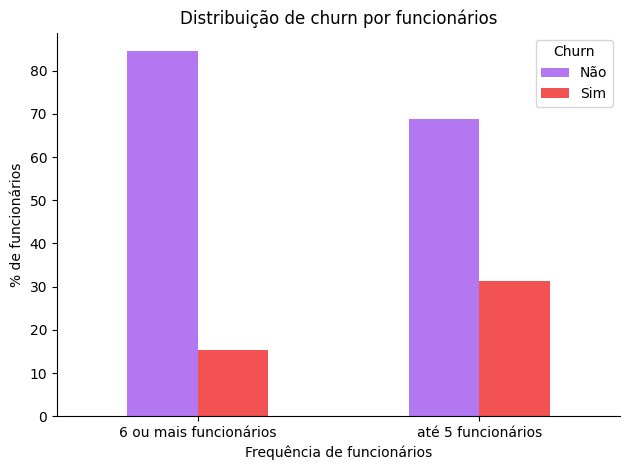

Churn,Não,Sim
Funcionários,,
6 ou mais funcionários,84.55,15.45
até 5 funcionários,68.72,31.28


In [25]:
# Tabela cruzada
crosstab = round(pd.crosstab(df['Funcionários'], df['Churn'], normalize='index') * 100,2) # o que é , normalize='index'?

# Visualização
crosstab = crosstab[['Não', 'Sim']]
ax =crosstab.plot(kind='bar', color= ['#B477F2', '#F25252'])

ax.spines['top'].set_visible(False)    # Remove borda de cima
ax.spines['right'].set_visible(False)

# Plotagem do gráfico
plt.title('Distribuição de churn por funcionários')
plt.xlabel('Frequência de funcionários')
plt.ylabel('% de funcionários')
plt.legend(title='Churn', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(crosstab)

- Clientes com até 5 funcionários apresentam churn significativamente maior (31,28%), enquanto empresas com 6 ou mais funcionários apresentam churn reduzido (15,45%), indicando que o porte da empresa influencia diretamente a retenção.

Churn x Utilização das features

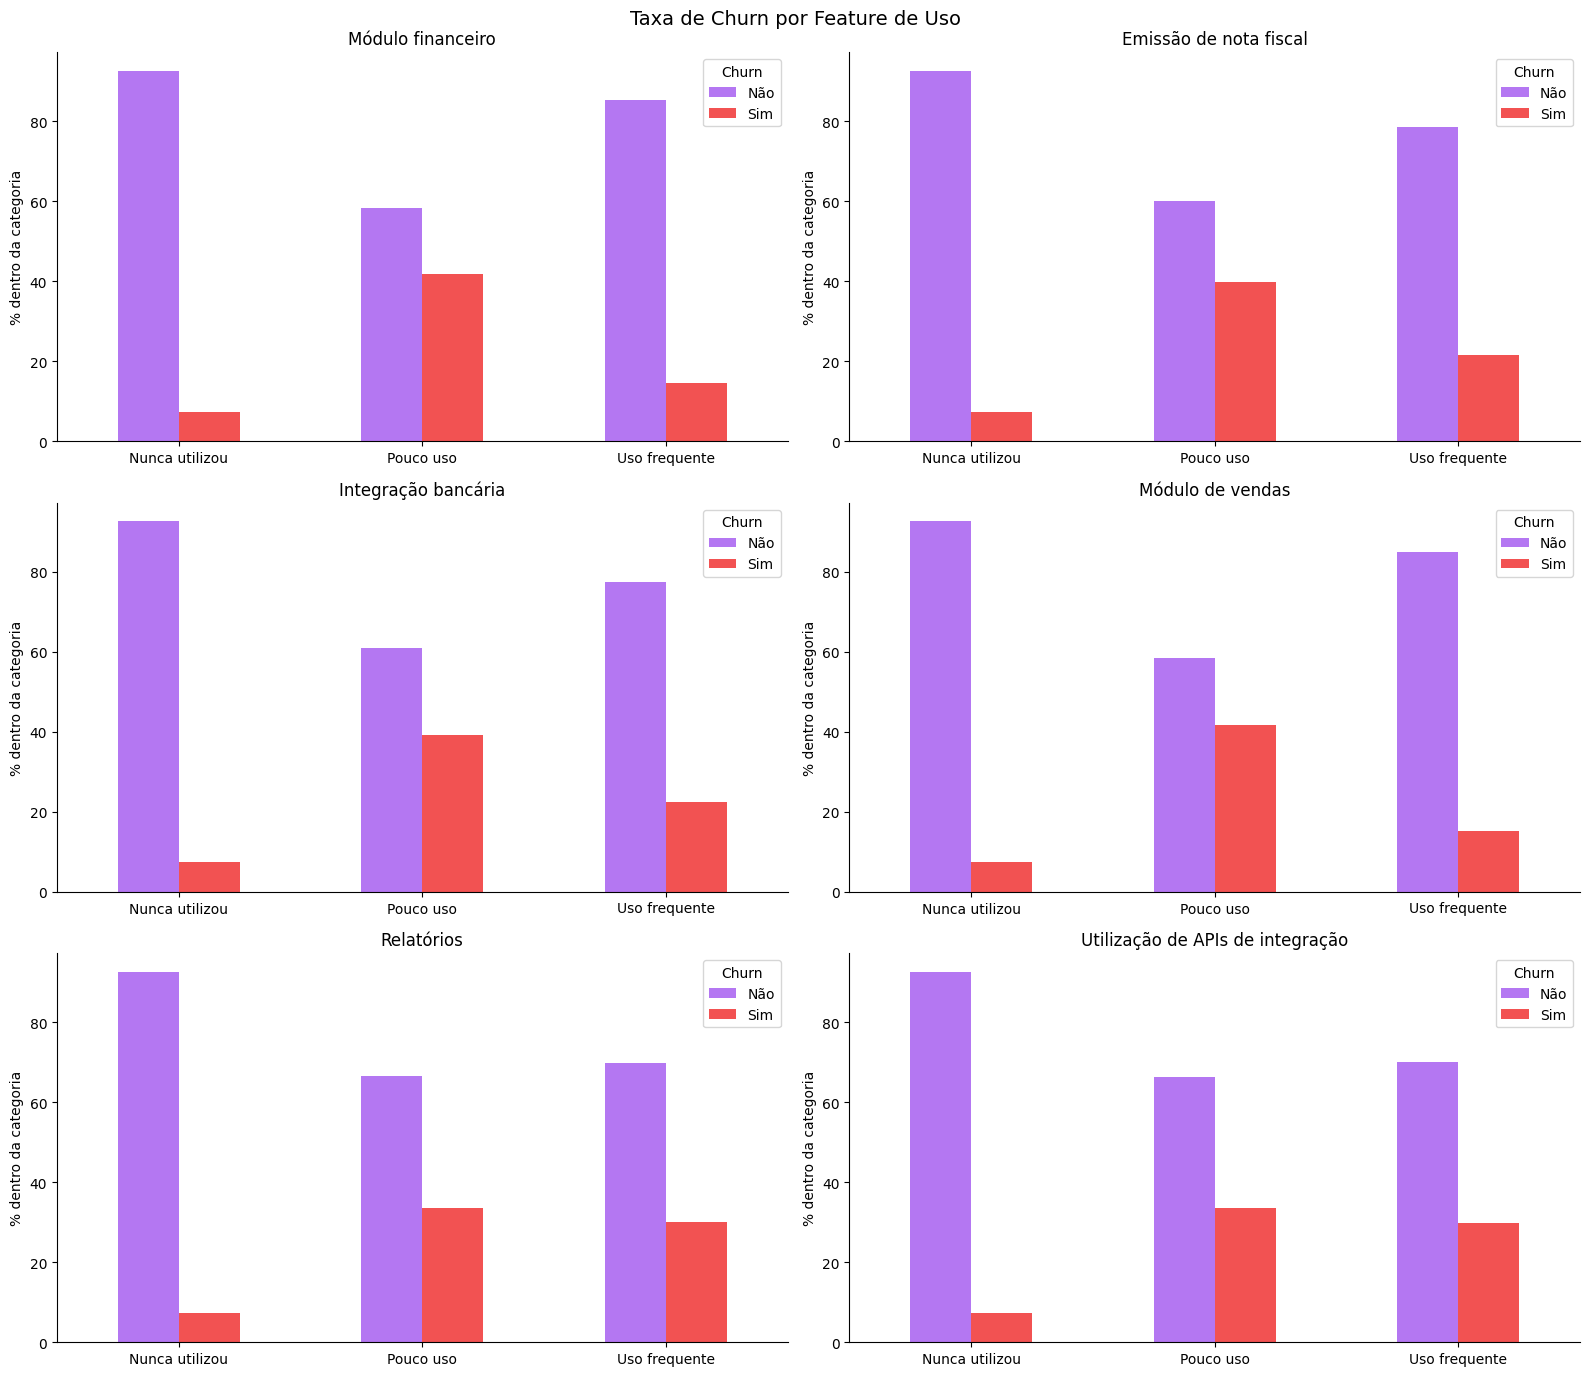


Módulo financeiro


Churn,Não,Sim
Frequência de utilização de feature do sistema: Módulo financeiro,,
Nunca utilizou,92.60,7.40
Pouco uso,58.23,41.77
Uso frequente,85.39,14.61



Emissão de nota fiscal


Churn,Não,Sim
Frequência de utilização de feature do sistema: Emissão de nota fiscal,,
Nunca utilizou,92.60,7.40
Pouco uso,60.07,39.93
Uso frequente,78.47,21.53



Integração bancária


...

Churn,Não,Sim
Frequência de utilização de feature do sistema: Módulo de vendas,,
Nunca utilizou,92.60,7.40
Pouco uso,58.36,41.64
Uso frequente,84.83,15.17



Relatórios


Churn,Não,Sim
Frequência de utilização de feature do sistema: Relatórios,,
Nunca utilizou,92.60,7.40
Pouco uso,66.48,33.52
Uso frequente,69.93,30.07



Utilização de APIs de integração


Churn,Não,Sim
Frequência de utilização de feature do sistema: Utilização de APIs de integração,,
Nunca utilizou,92.60,7.40
Pouco uso,66.32,33.68
Uso frequente,70.06,29.94


In [26]:
# @title
freq_cols = [
    'Frequência de utilização de feature do sistema: Módulo financeiro',
    'Frequência de utilização de feature do sistema: Emissão de nota fiscal',
    'Frequência de utilização de feature do sistema: Integração bancária',
    'Frequência de utilização de feature do sistema: Módulo de vendas',
    'Frequência de utilização de feature do sistema: Relatórios',
    'Frequência de utilização de feature do sistema: Utilização de APIs de integração'
]

fig, axs = plt.subplots(3, 2, figsize=(16, 14))

for i, col in enumerate(freq_cols):
    ax = axs[i//2, i%2]
    crosstab = round(pd.crosstab(df[col], df['Churn'], normalize='index') * 100, 2)
    crosstab[['Não', 'Sim']].plot(kind='bar', color=['#B477F2', '#F25252'], ax=ax)
    ax.set_title(col.replace('Frequência de utilização de feature do sistema: ', ''))
    ax.set_ylabel('% dentro da categoria')
    ax.set_xlabel('')
    ax.set_xticklabels(crosstab.index, rotation=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Taxa de Churn por Feature de Uso', fontsize=14)
plt.tight_layout()
plt.show()

for col in freq_cols:
    crosstab = round(pd.crosstab(df[col], df['Churn'], normalize='index') * 100, 2)
    print(f'\n{col.replace("Frequência de utilização de feature do sistema: ", "")}')
    display(crosstab)

- Clientes com pouco uso apresentam as maiores taxas de churn (~40%), indicando que a baixa adoção é o principal fator de cancelamento;
- Clientes que nunca utilizaram apresentam churn baixo (~7%), indicando que a experiência do cliente está em fase inicial;
- O uso frequente reduz o churn, mas não elimina totalmente, mostrando que engajamento ajuda, mas não é o único fator de retenção;
- Relatórios e APIs mantêm churn elevado mesmo com uso frequente (~30%), indicando possíveis problemas de valor percebido ou usabilidade;
- Módulo Financeiro e Vendas apresentam menor churn entre usuários apenas 14,61% e 15,17%;
- Há um padrão consistente: quanto menor o uso das funcionalidades, maior o churn, reforçando que o problema central está na adoção incompleta do sistema.

Churn x Tipo de contrato

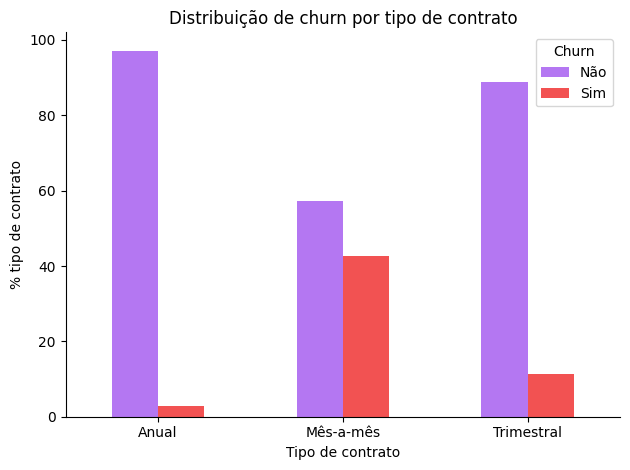

Churn,Não,Sim
Contrato,,
Anual,97.17,2.83
Mês-a-mês,57.29,42.71
Trimestral,88.73,11.27


In [27]:
# @title
# Tabela cruzada
crosstab = round(pd.crosstab(df['Contrato'], df['Churn'], normalize='index') * 100,2)

# Visualização
crosstab = crosstab[['Não', 'Sim']]
ax = crosstab.plot(kind='bar', color= ['#B477F2', '#F25252'])

ax.spines['top'].set_visible(False)    # Remove borda de cima
ax.spines['right'].set_visible(False)

#Gráfico
plt.title('Distribuição de churn por tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('% tipo de contrato')
plt.legend(title='Churn', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

crosstab

- Clientes com contrato mensal apresentam alto churn (42,71%), sendo o principal grupo de risco;
- Clientes com contratos trimestral e anual têm baixo churn, indicando maior retenção;
- Quanto maior o tempo de contrato, menor o churn, mostrando que o tipo de contrato é um forte indicador de cancelamento.

Churn x Receita mensal

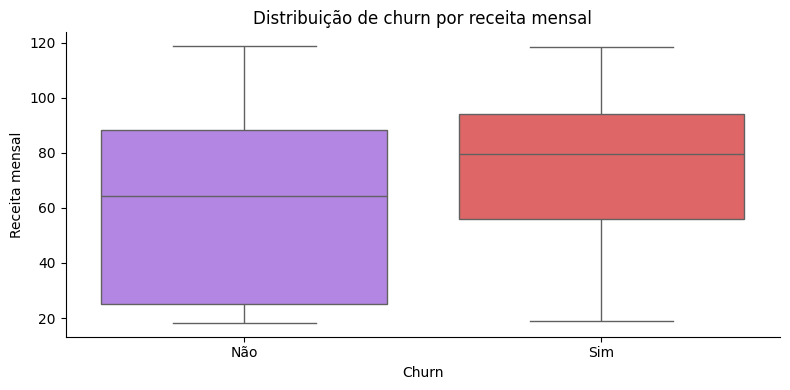

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Não,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Sim,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35


In [28]:
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(x='Churn', y='Receita mensal', data=df, hue='Churn', palette=['#B477F2', '#F25252'])
plt.title('Distribuição de churn por receita mensal')
plt.xlabel('Churn')
plt.ylabel('Receita mensal')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

#Estatística
est = round(df.groupby('Churn')['Receita mensal'].describe(),2)
est

- Clientes que cancelaram têm receita mensal mediana maior (79,65) do que os que não cancelaram (64,43). Isso é um resultado contraintuitivo, esperava-se que clientes de menor ticket cancelassem mais, mas os dados mostram o oposto. Vale investigar na análise bivariada.

Churn x Receita total

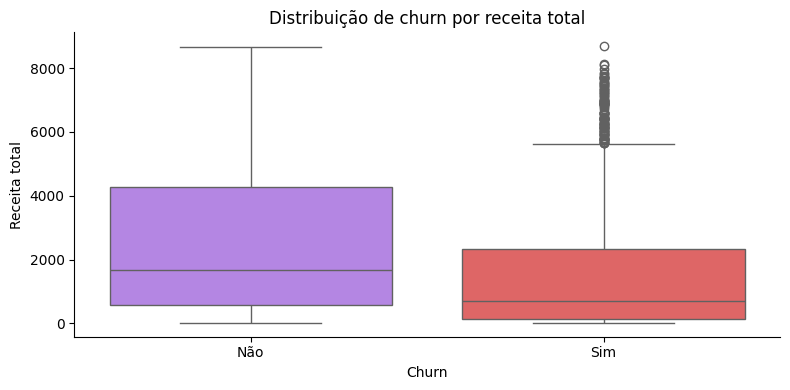

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Não,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Sim,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35


In [29]:
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(x='Churn', y='Receita total', data=df, hue='Churn', palette=['#B477F2', '#F25252'])
plt.title('Distribuição de churn por receita total')
plt.xlabel('Churn')
plt.ylabel('Receita total')
plt.xticks(rotation=0)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

#Estatística
est = round(df.groupby('Churn')['Receita mensal'].describe(),2)
est

Clientes que cancelaram têm receita total mediana significativamente menor R$ 877 comparado aos que não cancelaram (R$ 1.700). Isso faz sentido, quem cancela mais cedo acumula menos receita total, o que está diretamente relacionado com o tempo de permanência.

### Correlação

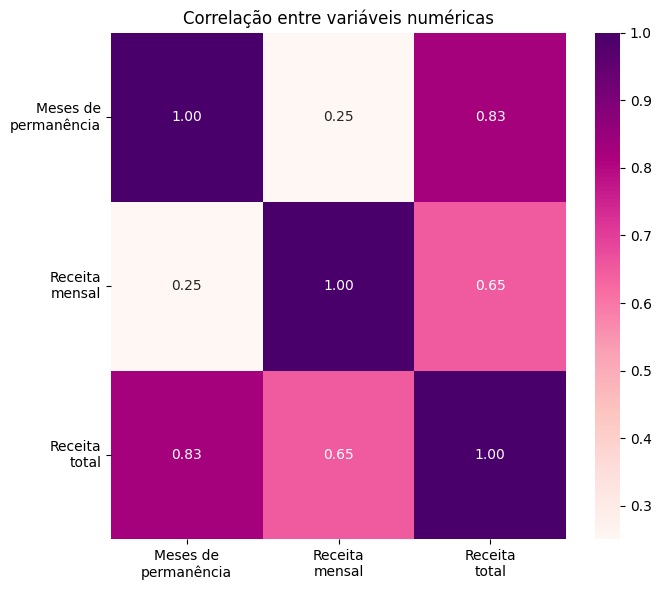

,Meses de permanência,Receita mensal,Receita total
Meses de permanência,1.00,0.25,0.83
Receita mensal,0.25,1.00,0.65
Receita total,0.83,0.65,1.00


In [30]:
# @title
# Selecionar variáveis numéricas relevantes
var_num = ['Meses de permanência', 'Receita mensal', 'Receita total']

nomes = {
    'Meses de permanência': 'Meses de\npermanência',
    'Receita mensal': 'Receita\nmensal',
    'Receita total': 'Receita\ntotal'
}

corr_matrix = round(df[var_num].corr(),2)
corr_plot = corr_matrix.rename(index=nomes, columns=nomes)


plt.figure(figsize=(7, 6))
sns.heatmap(corr_plot, annot=True, cmap='RdPu', fmt='.2f')
plt.title('Correlação entre variáveis numéricas')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

corr_matrix

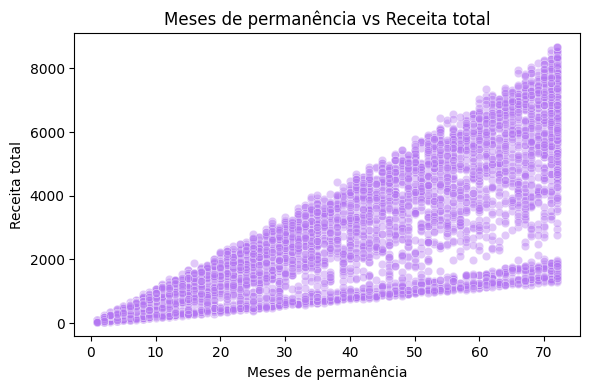

In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Meses de permanência', y='Receita total', data=df, alpha=0.4, color=['#B477F2'])
plt.title('Meses de permanência vs Receita total')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



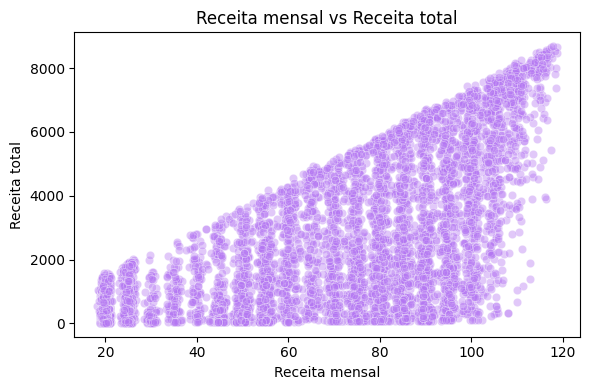

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Receita mensal', y='Receita total', data=df, alpha=0.4, color=['#B477F2'])
plt.title('Receita mensal vs Receita total')
plt.tight_layout()
plt.show()

**Correlação entre variáveis numéricas**

- **Meses de permanência x Receita total** (r = 0,83): correlação forte e positiva, quanto mais tempo o cliente permanece, maior a receita acumulada. Resultado esperado para modelos de assinatura;
- **Receita mensal x Receita total** (r = 0,65): correlação positiva e moderada, clientes com ticket mais alto tendem a acumular mais receita total, porém o tempo de permanência também influencia fortemente esse valor;
- **Meses de permanência x Receita mensal** (r = 0,25): correlação baixa, o valor do plano contratado não tem relação direta com o tempo de permanência do cliente.

## Conclusão
Esta análise exploratória investigou o comportamento de cancelamento de clientes de uma plataforma SaaS, identificando padrões e fatores associados ao churn.

- O tipo de contrato é o fator mais determinante — clientes com contrato mensal apresentam churn de 42,71%, enquanto clientes com contratos trimestrais e anuais têm taxas significativamente menores;
- O porte da empresa influencia diretamente — clientes com até 5 funcionários apresentam churn de 31,28%, contra 15,45% para empresas com 6 ou mais funcionários;
- A baixa adoção das features está associada ao cancelamento, clientes com pouco uso apresentam as maiores taxas de churn;
- Clientes que cancelaram apresentam receita total mediana menor (R\$ 877), indicando que o cancelamento ocorre cedo no ciclo de vida;
- Resultado contraintuitivo: clientes que cancelaram têm receita mensal maior (R\$ 79,65), sugerindo que o valor do plano não é o principal motivador do cancelamento;
- Houve aumento na taxa de churn de abril (12,93%) para maio (15,62%), porém com apenas 2 meses não é possível confirmar tendência.

Recomendações

- Incentivar contratos de maior duração com descontos ou benefícios para clientes que migrarem do plano mensal;
- Criar um programa de onboarding para os 1.526 clientes que nunca utilizaram nenhuma feature, esse grupo representa alto risco de cancelamento;
- Priorizar ações de retenção para empresas com até 5 funcionários, que concentram 70% da base e apresentam maior churn;
- Monitorar a evolução mensal do churn nos próximos meses para identificar se o aumento observado é uma tendência;
- Investigar o perfil dos clientes com maior receita mensal que cancelaram, uma vez que esse comportamento pode indicar insatisfação com o produto além do fator financeiro.